In [1]:
import pickle

import numpy as np
from numpy import random as rnd
from matplotlib import pyplot as plt
from tqdm import autonotebook as tqdm

from sklearn.model_selection import train_test_split
from utils import find_energies, numerov

/var/folders/xb/gm1t4x5j3sbby4s80ty5k3z40000gn/T/ipykernel_52794/982083896.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm import autonotebook as tqdm


In [2]:
from lightgbm import LGBMRegressor

In [3]:
with open("data/dataset.bin", mode="rb") as fh:
    data = pickle.load(fh)

In [4]:
x = np.array(data[0]["space"])

In [5]:
num_examples = len(data)
num_points = len(data[0]["space"])

potentials = np.zeros((num_examples, num_points))
wave_functions = np.zeros((num_examples, num_points))
energies = np.zeros((num_examples, 4))
num_levels = np.zeros(num_examples)

for k, item in enumerate(data):
    potentials[k] = item["potential"]
    wave_functions[k] = item["states"][0]["wave_function"]
    energies[k, 0:len(item["states"])] = [state["energy"] for state in item["states"]]
    num_levels[k] = len(item["states"])
    
    

In [6]:
train_pot, test_pot, train_wf, test_wf, train_en, test_en = train_test_split(potentials, wave_functions, energies)

In [7]:
model = LGBMRegressor()

model.fit(train_pot, train_en[:, 0])

LGBMRegressor()

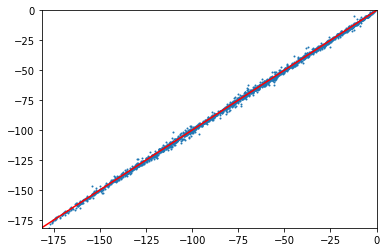

In [8]:
pred_en = model.predict(test_pot)
e_min, e_max = (test_en[:, 0].min(), test_en[:, 0].max())
fig, ax = plt.subplots()
ax.scatter(pred_en, test_en[:, 0], s=1)
ax.set_xlim(e_min, 0)
ax.set_ylim(e_min, 0)
ax.plot([e_min, 0], [e_min, 0], color="red")

  0%|          | 0/11 [00:00<?, ?it/s]

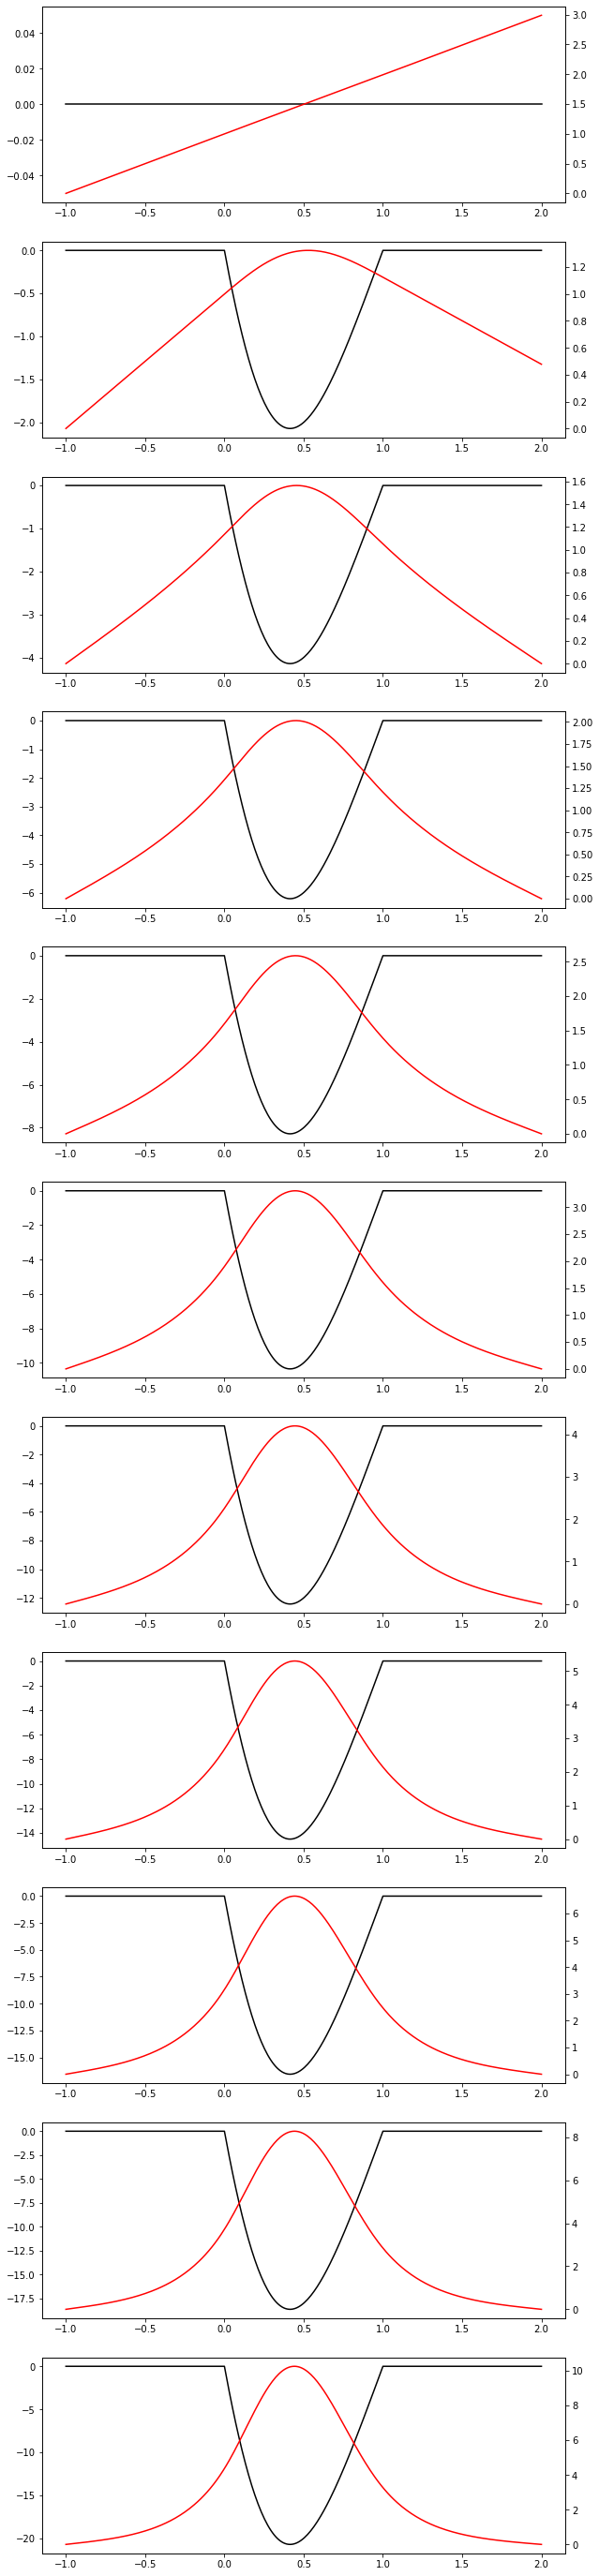

In [100]:
scales = np.linspace(0, 2, 11)
actual_energies = np.zeros_like(scales)
pred_energies = np.zeros_like(scales)

fig, ax = plt.subplots(figsize=(10, 50), nrows=len(scales))

for k, scale in enumerate(tqdm.tqdm(scales)):
    potential = np.where((x > 0) & (x < 1), -scale * 50 * (x * (1-x)/(1 + x*x)), 0)
    results = [e for (e, _) in find_energies(x, potential, grid_size=1001)]
    actual_energies[k] = min(results, default=0)
    pred_energies[k] = model.predict([potential])[0]
    psi = numerov(x, potential, actual_energies[k])
    ax[k].plot(x, potential, color="black")
    ax[k].twinx().plot(x, psi, color="red")

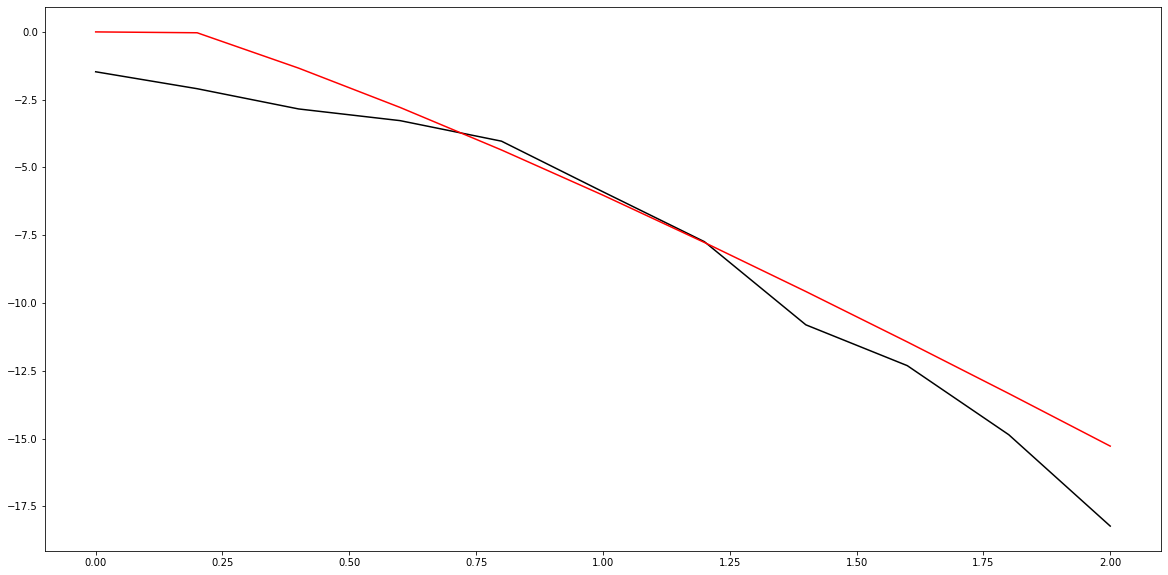

In [98]:
fig, ax = plt.subplots(figsize=(20, 10))

ax.plot(scales, pred_energies, color="black")
ax.plot(scales, actual_energies, color="red")